# Task 3 – Compare Semantic Contexts (20260323)

For each focal term:
1. Extract its **patent context**: all other terms in the same patent.
2. Extract its **paper context**: union of all terms in the cited papers where the focal term appears.
3. Represent each context as a sentence and encode it with a sentence transformer.
4. Compute **cosine similarity** between patent context and paper context.

High similarity → the term is used in a similar semantic environment in both domains.  
Low similarity → the term means something different in patents vs. science.

## Step 1 – Load data and rebuild focal_term → PMID mapping

In [1]:
import pandas as pd

# Load pre-computed focal terms from task 1
df_focal = pd.read_parquet('../output/focal_terms_20260323.parquet')

# Raw files needed to build contexts
df_pat  = pd.read_parquet('../data/raw/SampleGloria_Pat_GlinerLabels_20260323.parquet')
df_pmed = pd.read_parquet('../data/raw/SampleGloria_Pmed_GlinerLabels_20260323.parquet')
df_link = pd.read_parquet('../data/raw/SampleGloria_Link_PmidOa_20260323.parquet')

print('Focal term rows:', len(df_focal))
print('Pat rows: ', len(df_pat))
print('Pmed rows:', len(df_pmed))
print('Link rows:', len(df_link))

Focal term rows: 19145
Pat rows:  16894907
Pmed rows: 510752
Link rows: 2841978


In [2]:
# Clean link: drop duplicate (patent_id, pmid) pairs from multiple matching sources
df_link_clean = df_link[['patent_id', 'pmid']].drop_duplicates()
print('Unique patent-pmid pairs:', len(df_link_clean))

Unique patent-pmid pairs: 2828161


In [3]:
# For each (patent_id, focal_term), find the PMIDs of cited papers that contain the focal term
cited_terms = (
    df_pmed[['pmid', 'term']]
    .merge(df_link_clean, on='pmid', how='inner')
)

focal_with_pmid = (
    df_focal[['patent_id', 'focal_term']]
    .merge(
        cited_terms[['patent_id', 'pmid', 'term']].drop_duplicates()
                   .rename(columns={'term': 'focal_term'}),
        on=['patent_id', 'focal_term'],
        how='inner'
    )
)

print('focal_with_pmid shape:', focal_with_pmid.shape)
focal_with_pmid.head()

focal_with_pmid shape: (44844, 3)


,patent_id,focal_term,pmid
0,9949959,pirfenidone,21659848
1,10145926,imaging,12541226
2,10145926,imaging,12886146
3,10145926,imaging,15389936
4,10145926,imaging,17243585


## Step 2 – Build patent context per (patent_id, focal_term)

Patent context = **set of all terms in the patent** minus the focal term itself.

In [4]:
patent_term_sets = (
    df_pat.groupby('patent_id')['term']
          .apply(set)
          .to_dict()
)
print('Patents with term sets:', len(patent_term_sets))

Patents with term sets: 180000


## Step 3 – Build paper context per (patent_id, focal_term)

Paper context = **union of all terms** in the cited PMIDs where the focal term appears, minus the focal term itself.

In [5]:
# For each (patent_id, focal_term) → set of relevant PMIDs
focal_pmids = (
    focal_with_pmid.groupby(['patent_id', 'focal_term'])['pmid']
                   .apply(set)
                   .reset_index(name='pmid_set')
)

# dict: pmid -> set of terms
pmid_term_sets = (
    df_pmed.groupby('pmid')['term']
           .apply(set)
           .to_dict()
)
print('PMIDs with term sets:', len(pmid_term_sets))

PMIDs with term sets: 177916


In [6]:
def paper_context(pmid_set, focal_term):
    """Union of terms across the relevant PMIDs, minus the focal term."""
    terms = set()
    for pmid in pmid_set:
        terms |= pmid_term_sets.get(pmid, set())
    terms.discard(focal_term)
    return terms

focal_pmids['paper_ctx'] = focal_pmids.apply(
    lambda r: paper_context(r['pmid_set'], r['focal_term']), axis=1
)
focal_pmids.head(3)

,patent_id,focal_term,pmid_set,paper_ctx
0,10000506,thienopyridine,{17982182},"{gov, prasugrel, moderate-to-high-risk, target..."
1,10000699,photoluminescence,{19206236},"{nanorod, imaging, nanorods}"
2,10000734,fucosylation,{11784152},"{heptasaccharide, changing, chemoenzymatic, co..."


## Step 4 – Build context table

In [7]:
rows = []
for _, row in focal_pmids.iterrows():
    pid    = row['patent_id']
    ft     = row['focal_term']
    pat_ctx = patent_term_sets.get(pid, set()) - {ft}
    pap_ctx = row['paper_ctx']
    rows.append({
        'patent_id':      pid,
        'focal_term':     ft,
        'pmids':          row['pmid_set'],
        'patent_context': pat_ctx,
        'paper_context':  pap_ctx
    })

focal_term_contexts = pd.DataFrame(rows)
print(focal_term_contexts.shape)
focal_term_contexts.head()

(19145, 5)


,patent_id,focal_term,pmids,patent_context,paper_context
0,10000506,thienopyridine,{17982182},"{acetone, cyano, bicarbonate, derivative, sodi...","{gov, prasugrel, moderate-to-high-risk, target..."
1,10000699,photoluminescence,{19206236},"{optical, ar, shell, nanoparticle, value, and,...","{nanorod, imaging, nanorods}"
2,10000734,fucosylation,{11784152},"{essentially, subculturing, bone, sialyl-lewis...","{heptasaccharide, changing, chemoenzymatic, co..."
3,10000741,transgene,"{15824224, 24010979, 17622469, 18209734, 12657...","{aav, disease, introduced, expression, essenti...","{lenti, pseudotyping, lentiviral, humanely, ad..."
4,10000800,sequencing,"{22701568, 21562209, 18337506, 16081699, 20628...","{next generation, appears, high, attached, to,...","{sequencing-by-synthesis, cost-effectively, kb..."


## Step 5 – Encode contexts with sentence transformer

In [8]:
# Represent each context as: "focal_term term1 term2 term3 ..."
patent_sentences = [
    f"{row['focal_term']} {' '.join(row['patent_context'])}"
    for _, row in focal_term_contexts.iterrows()
]
paper_sentences = [
    f"{row['focal_term']} {' '.join(row['paper_context'])}"
    for _, row in focal_term_contexts.iterrows()
]

In [9]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

patent_embeddings = model.encode(patent_sentences, show_progress_bar=True, batch_size=256)
paper_embeddings  = model.encode(paper_sentences,  show_progress_bar=True, batch_size=256)

print('patent_embeddings shape:', patent_embeddings.shape)
print('paper_embeddings shape: ', paper_embeddings.shape)

/Users/gloria/Library/Caches/pypoetry/virtualenvs/hiwi-02P-lfTy-py3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8157.66it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 75/75 [00:50<00:00,  1.47it/s]

patent_embeddings shape: (19145, 384)
paper_embeddings shape:  (19145, 384)


## Step 6 – Compute cosine similarity

In [14]:
from sklearn.metrics.pairwise import cosine_similarity

similarities = cosine_similarity(patent_embeddings, paper_embeddings).diagonal()
focal_term_contexts['cosine_similarity'] = similarities

print(focal_term_contexts[['patent_id', 'focal_term', 'cosine_similarity']].head(20))

   patent_id         focal_term  cosine_similarity
0   10000506     thienopyridine           0.176216
1   10000699  photoluminescence           0.390401
2   10000734       fucosylation           0.561903
3   10000741          transgene           0.391839
4   10000800         sequencing           0.421235
5   10000814          cediranib           0.298092
6   10000814         crizotinib           0.349171
7   10000814           encoding           0.248174
8   10000814          gefitinib           0.359919
9   10000814           in-frame           0.135725
10  10000814          lapatinib           0.398282
11  10000814       lestaurtinib           0.434179
12  10000814         sequencing           0.281620
13  10001442           graphene           0.370162
14  10001614           graphene           0.574749
15  10002311           training           0.325148
16  10002419           modeling           0.163581
17  10002927           graphene           0.280948
18  10003034            alkynyl

## Step 7 – Save results

In [15]:
focal_term_contexts.to_parquet('../output/cosine_similarity_results_20260323.parquet', index=False)
print('Saved: cosine_similarity_results_20260323.parquet')

Saved: cosine_similarity_results_20260323.parquet


## Step 8 – Visualizations

=== Cosine Similarity Statistics ===
  Mean:   0.379
  Median: 0.384
  Std:    0.128
  Min:    -0.082
  Max:    0.799


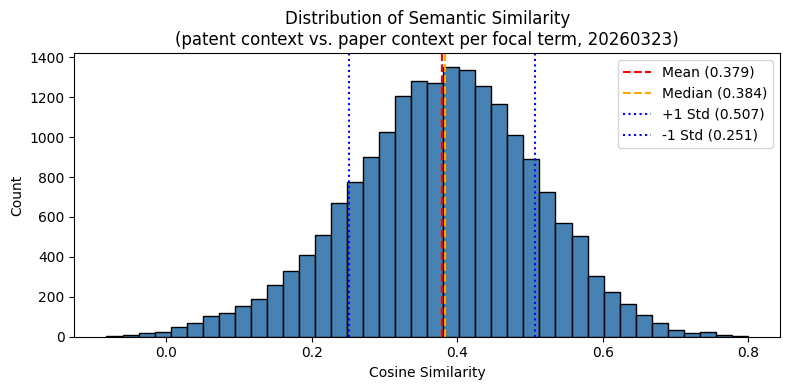

In [16]:
import matplotlib.pyplot as plt

sim = focal_term_contexts['cosine_similarity']

print('=== Cosine Similarity Statistics ===')
print(f'  Mean:   {sim.mean():.3f}')
print(f'  Median: {sim.median():.3f}')
print(f'  Std:    {sim.std():.3f}')
print(f'  Min:    {sim.min():.3f}')
print(f'  Max:    {sim.max():.3f}')

plt.figure(figsize=(8, 4))
plt.hist(sim, bins=40, edgecolor='black', color='steelblue')
plt.axvline(sim.mean(),             color='red',    linestyle='--', label=f'Mean ({sim.mean():.3f})')
plt.axvline(sim.median(),           color='orange', linestyle='--', label=f'Median ({sim.median():.3f})')
plt.axvline(sim.mean()+sim.std(),   color='blue',   linestyle=':',  label=f'+1 Std ({sim.mean()+sim.std():.3f})')
plt.axvline(sim.mean()-sim.std(),   color='blue',   linestyle=':',  label=f'-1 Std ({sim.mean()-sim.std():.3f})')
plt.xlabel('Cosine Similarity')
plt.ylabel('Count')
plt.title('Distribution of Semantic Similarity\n(patent context vs. paper context per focal term, 20260323)')
plt.legend()
plt.tight_layout()
plt.savefig('../visualizations/cosine_similarity_distribution_20260323.png', dpi=150)
plt.show()

## Step 9 – Examples: highest and lowest similarity

In [17]:
n = 5
top = focal_term_contexts.nlargest(n, 'cosine_similarity')
bot = focal_term_contexts.nsmallest(n, 'cosine_similarity')

print('=== HIGH similarity (term used in similar context in patents and papers) ===')
for _, row in top.iterrows():
    print(f"\nFocal term: '{row['focal_term']}' (patent={row['patent_id']}, sim={row['cosine_similarity']:.3f})")
    print(f"  Patent ctx: {', '.join(list(row['patent_context'])[:10])}")
    print(f"  Paper  ctx: {', '.join(list(row['paper_context'])[:10])}")

print('\n=== LOW similarity (term used in different context) ===')
for _, row in bot.iterrows():
    print(f"\nFocal term: '{row['focal_term']}' (patent={row['patent_id']}, sim={row['cosine_similarity']:.3f})")
    print(f"  Patent ctx: {', '.join(list(row['patent_context'])[:10])}")
    print(f"  Paper  ctx: {', '.join(list(row['paper_context'])[:10])}")

=== HIGH similarity (term used in similar context in patents and papers) ===

Focal term: 'sildenafil' (patent=8653051, sim=0.799)
  Patent ctx: prior, is, short, one, demand, formulation, treatment, subject, inhibitor, selected
  Paper  ctx: 24weeks, 50, phosphodiesterase-5, vardenafil, tadalafil

Focal term: 'tadalafil' (patent=8653051, sim=0.794)
  Patent ctx: prior, is, short, one, sildenafil, demand, formulation, treatment, subject, inhibitor
  Paper  ctx: 24weeks, 50, phosphodiesterase-5, vardenafil, sildenafil

Focal term: 'glucono-δ-lactone' (patent=8703452, sim=0.790)
  Patent ctx: activity, having, polypeptide, hexose-δ-lactone, contacting, seq, aldonic acid, recombinant, at, sequence
  Paper  ctx: deconstruct, known, lactonase

Focal term: 'vardenafil' (patent=8653051, sim=0.788)
  Patent ctx: prior, is, short, one, sildenafil, demand, formulation, treatment, subject, inhibitor
  Paper  ctx: 24weeks, 50, phosphodiesterase-5, tadalafil, sildenafil

Focal term: 'atazanavir' (p